<a href="https://colab.research.google.com/github/SSenitha/Data_Analytics/blob/Sandaru's/InferentialAnalysis_sandaru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analysis of Rain in Australia
This notebook contains all the steps of the analysis: From data cleaning and preprocessing to the conclusions.

In [53]:
# Load data from the repository
!wget https://raw.githubusercontent.com/SSenitha/Data_Analytics/main/weatherAUS.csv

--2025-09-18 12:33:32--  https://raw.githubusercontent.com/SSenitha/Data_Analytics/main/weatherAUS.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14094055 (13M) [text/plain]
Saving to: ‘weatherAUS.csv.1’

weatherAUS.csv.1    100%[===================>]  13.44M  --.-KB/s    in 0.1s    

2025-09-18 12:33:33 (111 MB/s) - ‘weatherAUS.csv.1’ saved [14094055/14094055]



In [54]:
#Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import stats

#Data Cleaning

In [55]:
# Read the dataset and output the total count
df = pd.read_csv('/content/weatherAUS.csv')
print(f"Total rows count: {df['RainToday'].count()}")
df.head()

Total rows count: 142199


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


##1. De-duplication

In [56]:
# Check for duplicate rows and removing, keeping the first occurrence
print(df.duplicated().sum())
df_cleaned = df.drop_duplicates()

0


##2. Null Value Handeling

In [57]:
# Check for the missing values
missing_values_count = df.isnull().sum()
print(missing_values_count)

# Calculate the percent of data that is missing
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100
print(f"Percentage of missing values: {percent_missing}")

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64
Percentage of missing values: 10.259745694319072


In [58]:
df_cleaned = df

# Remove the rows that has missing result
df_cleaned.dropna(subset=['RainToday'], inplace=True)
df_cleaned.dropna(subset=['RainTomorrow'], inplace=True)
#print(df.head())

# Check the remaining value count
print(f"Total rows Left: {df['RainToday'].count()}")

Total rows Left: 140787


In [59]:
numerical_cols = df.select_dtypes(include=['float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna('')

##3. Standardization

In [60]:
# convert the date column into a datetime object
df_cleaned['Date'] = pd.to_datetime(df['Date'], format="%Y-%m-%d")

# extract the day, month, and year components
df_cleaned['Day'] = df_cleaned['Date'].dt.day
df_cleaned['Month'] = df_cleaned['Date'].dt.month
df_cleaned['Year'] = df_cleaned['Date'].dt.year

In [61]:
#Removing unwanted columns
#df_cleaned.drop(['Date'], axis=1, inplace=True)
#df_cleaned.drop(['WindGustDir'], axis=1, inplace=True)
df_cleaned.drop(['WindDir9am'], axis=1, inplace=True)
df_cleaned.drop(['WindDir3pm'], axis=1, inplace=True)

In [62]:
# Map binary variables
df_cleaned['RainTomorrow'] = df_cleaned['RainTomorrow'].map({'Yes': 1, 'No': 0})
df_cleaned['RainToday'] = df_cleaned['RainToday'].map({'Yes': 1, 'No': 0})

In [63]:
df_cleaned.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindSpeed9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Day,Month,Year
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.5,W,44.0,20.0,...,1007.1,8.0,5.0,16.9,21.8,0,0,1,12,2008
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44.0,4.0,...,1007.8,5.0,5.0,17.2,24.3,0,0,2,12,2008
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46.0,19.0,...,1008.7,5.0,2.0,21.0,23.2,0,0,3,12,2008
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.5,NE,24.0,11.0,...,1012.8,5.0,5.0,18.1,26.5,0,0,4,12,2008
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.5,W,41.0,7.0,...,1006.0,7.0,8.0,17.8,29.7,0,0,5,12,2008


#Inferential Analysis

In [64]:
# Get a copy of dataset for the analysis
df_inferential = df_cleaned

##HA1: Does humidity significantly differ between rainy and dry days?

In [65]:
# Get the data required
df_inferential['HumidityAvg'] = (df_inferential['Humidity9am'] + df_inferential['Humidity3pm'])/2
Humidity = df_inferential[['HumidityAvg', 'RainTomorrow']]
Humidity.head()

HumidityOnPredictedRain = Humidity[Humidity['RainTomorrow'] == 1]['HumidityAvg']
HumidityOnPredictedNoRain = Humidity[Humidity['RainTomorrow'] == 0]['HumidityAvg']

HumidityOnPredictedRain.head()

,HumidityAvg
8,25.5
10,35.0
11,90.0
12,84.5
16,75.5


since the dataset is large and >30, the T-test will perform well. But normality assesment is done to make sure that the set doesn't have large deviations, thus violating the normality conditions required for Paired sample T-test

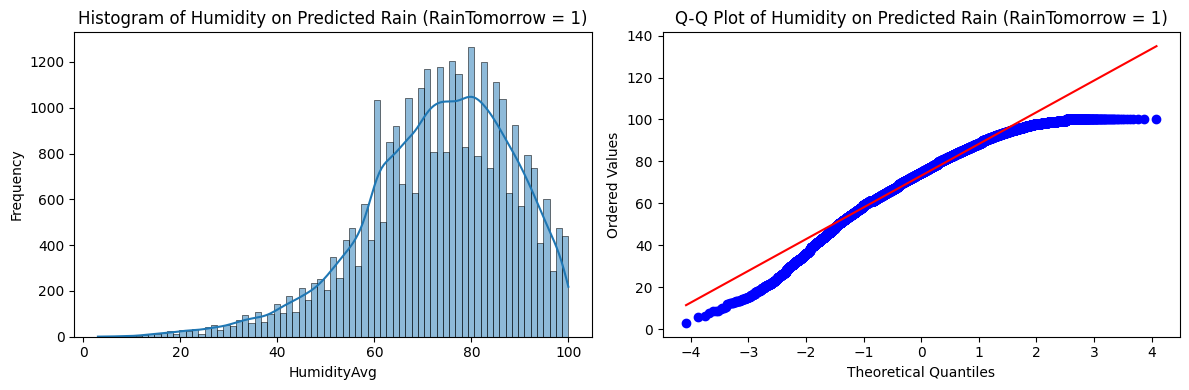

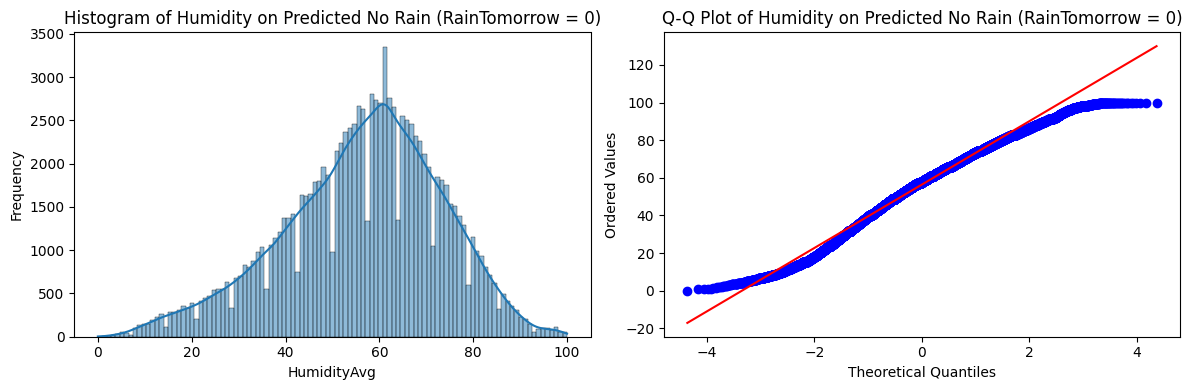

In [66]:
from scipy import stats
import math

cols = [HumidityOnPredictedRain, HumidityOnPredictedNoRain]
titles = ['Humidity on Predicted Rain (RainTomorrow = 1)', 'Humidity on Predicted No Rain (RainTomorrow = 0)']

for i, col in enumerate(cols):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(col, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of {titles[i]}')
    axes[0].set_xlabel('HumidityAvg')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    stats.probplot(col.dropna(), dist='norm', plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {titles[i]}')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Ordered Values')

    plt.tight_layout()
    plt.show()

Since the deviation from the normality is higher, the Mann-whitney U test is chosen over paired sample T-test.
<br><br>

**Hypothesis Definition for Mann-whitney U test**

* H0 (Null hypothesis) = There is no difference in average humidity between days followed by rain and days not followed by rain.

* H1 (Alternative hypothesis) = There is a difference in average humidity between days followed by rain and days not followed by rain.

In [67]:
from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U test
statistic, p_value = mannwhitneyu(HumidityOnPredictedRain, HumidityOnPredictedNoRain, alternative='greater')

# Print the results
print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a difference in average humidity between days followed by rain and days not followed by rain.")
else:
    print("Fail to reject the null hypothesis: There is no difference in average humidity between days followed by rain and days not followed by rain.")

Mann-Whitney U statistic: 2646602549.0
P-value: 0.0
Reject the null hypothesis: There is a difference in average humidity between days followed by rain and days not followed by rain.


##HA2: Is rainfall today associated with the probability of rain tomorrow?

The the test perfomed on HA2 is to check the assosciation between the rain today and the rain tomorrow. The Chi-squared Test of Independance is used.

In [68]:
from scipy.stats import chi2_contingency

# Create a contingency table of RainToday and RainTomorrow
contingency_table = pd.crosstab(df_inferential['RainToday'], df_inferential['RainTomorrow'])
print(contingency_table)

RainTomorrow      0      1
RainToday                 
0             92728  16604
1             16858  14597


Since the two vriables are categorical, the Chi Squared test is used to assess the dependancy of tomorrows rain on the rain conditions of today.
<br><br>

**Hypothesis Definition for Chi Squared test**

* H0 (Null hypothesis) = Rainfall today does not have an effect on the rainfall tomorrow.

* H1 (Alternative hypothesis) = Rainfall today has an effect on the rainfall tomorrow.

In [69]:
# Perform the Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the results
print("Results of the Chi-square test:")
print(f"Chi-square statistic = {chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"P-value = {p:.4f}\n")

print("Expected frequencies:")
print(expected)

alpha = 0.05
if p < alpha:
    print("\nReject the null hypothesis: Rainfall today has an effect on the rainfall tomorrow.")
else:
    print("\nFail to reject the null hypothesis: Rainfall today does not have an effect on the rainfall tomorrow.")

Results of the Chi-square test:
Chi-square statistic = 13799.4796
Degrees of freedom = 1
P-value = 0.0000

Expected frequencies:
[[85102.00907754 24229.99092246]
 [24483.99092246  6971.00907754]]

Reject the null hypothesis: Rainfall today has an effect on the rainfall tomorrow.


##HA3: Do average temperatures differ significantly between rainy and dry days?

In [70]:
# Get the data required
df_inferential['TempAvg'] = (df_inferential['Temp9am'] + df_inferential['Temp3pm'])/2
Temp = df_inferential[['TempAvg', 'RainTomorrow']]
Temp.head()

TempTodayOnPredictedRain = Temp[Temp['RainTomorrow'] == 1]['TempAvg']
TempTodayOnPredictedNoRain = Temp[Temp['RainTomorrow'] == 0]['TempAvg']

TempTodayOnPredictedRain.head()

,TempAvg
8,24.25
10,24.60
11,16.45
12,16.60
16,17.65


Since the dataset size > 30, we can proceed with the T-test. Before proceeding we will check for the normality using QQ plots since Shapiro-Wilk test is not pretty accurate for the given size of data (*UserWarning: scipy.stats.shapiro: For N > 5000*)

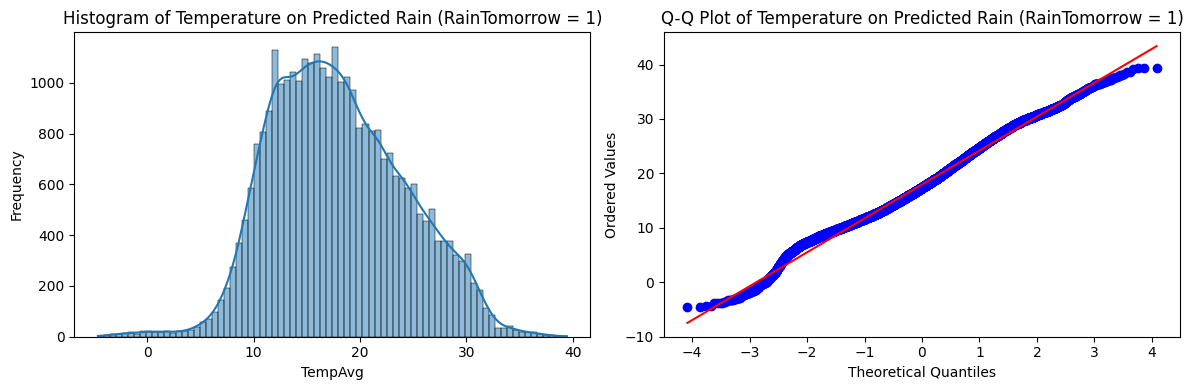

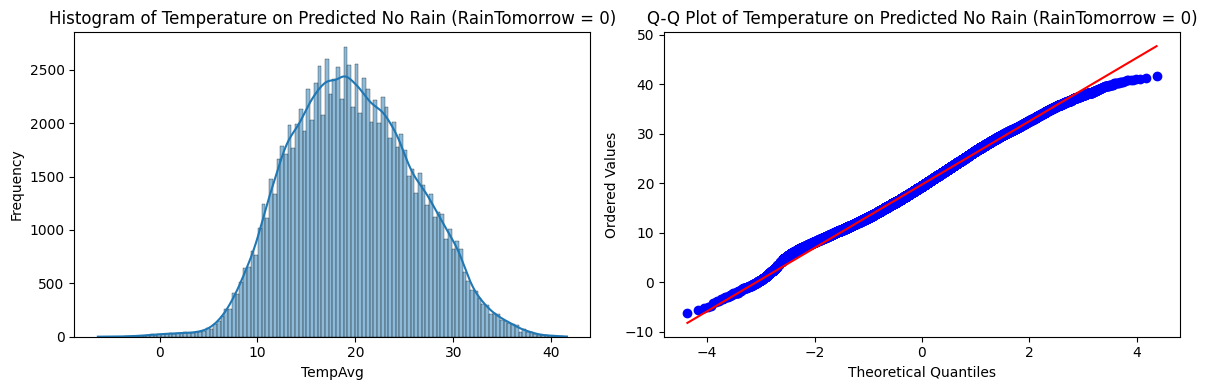

In [71]:
from scipy import stats
import math

cols = [TempTodayOnPredictedRain, TempTodayOnPredictedNoRain]
titles = ['Temperature on Predicted Rain (RainTomorrow = 1)', 'Temperature on Predicted No Rain (RainTomorrow = 0)']

for i, col in enumerate(cols):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(col, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of {titles[i]}')
    axes[0].set_xlabel('TempAvg')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    stats.probplot(col.dropna(), dist='norm', plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {titles[i]}')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Ordered Values')

    plt.tight_layout()
    plt.show()

Since the dataset is large and almost normal we can proceed with the Paired Sample T-Test to test the association between the variables
<br><br>

**Hypothesis Definition for Paired sample T-Test**

*   H0 (Null hypothesis) = There is no difference in the distribution of average temperatures between days followed by rain and days not followed by rain.
*   H1 (Alternative hypothesis) = There is a difference in the distribution of average temperatures between days followed by rain and days not followed by rain.

In [72]:
# Perform paired sample T-Test
t_statistic, pvalue = stats.ttest_rel(df_inferential['TempAvg'], df_inferential['RainTomorrow'])

print("Results of the Chi-square test:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {pvalue:.4f}")


alpha = 0.05
if p_value < alpha:
    print("\nReject the null hypothesis: There is a significant difference in the distribution of average temperatures between days followed by rain and days not followed by rain.")
else:
    print("\nFail to reject the null hypothesis: There is no significant difference in the distribution of average temperatures between days followed by rain and days not followed by rain.")

Results of the Chi-square test:
T-statistic: 1106.9262
P-value: 0.0000

Reject the null hypothesis: There is a significant difference in the distribution of average temperatures between days followed by rain and days not followed by rain.


##HA4: Is there a significant association between wind direction and rain occurrence?

In [73]:
# Get the data required
Wind = df_inferential[['WindGustDir', 'RainTomorrow']]
Wind.head()

WindTodayOnPredictedRain = Wind[Wind['RainTomorrow'] == 1]['WindGustDir']
WindTodayOnPredictedNoRain = Wind[Wind['RainTomorrow'] == 0]['WindGustDir']

WindTodayOnPredictedRain.head()

,WindGustDir
8,NNW
10,N
11,NNE
12,W
16,ENE


**Hypothesis Definition for Chi-Squared test**

*   H0 (Null hypothesis): Wind direction is independent of whether it rains tomorrow.
*   H1 (Alternative hypothesis): Wind direction is associated with whether it rains tomorrow.

In [76]:
from scipy.stats import chi2_contingency

# Create a contingency table of WindGustDir and RainTomorrow
contingency_table_wind = pd.crosstab(df_inferential['WindGustDir'], df_inferential['RainTomorrow'])

# Perform the Chi-square test
chi2_wind, p_wind, dof_wind, expected_wind = chi2_contingency(contingency_table_wind)

# Print the results
print("Results of the Chi-square test:")
print(f"Chi-square statistic: {chi2_wind:.4f}")
print(f"P-value: {p_wind:.4f}")
print(f"Degrees of freedom: {dof_wind}")

alpha = 0.05
if p_wind < alpha:
    print("\nReject the null hypothesis: Wind direction is associated with whether it rains tomorrow.")
else:
    print("\nFail to reject the null hypothesis: Wind direction is independent of whether it rains tomorrow.")

Results of the Chi-square test:
Chi-square statistic: 1593.4079
P-value: 0.0000
Degrees of freedom: 16

Reject the null hypothesis: Wind direction is associated with whether it rains tomorrow.


##HA5: Do rainfall amounts significantly vary between different cities?

In [95]:
from scipy.stats import f_oneway, kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# Get the data required
top_cities = df_inferential["Location"].value_counts().index[:10]
subset = df_inferential[df_inferential["Location"].isin(top_cities)].dropna(subset=["Rainfall"])

# Prepare groups
groups = [subset[subset["Location"] == city]["Rainfall"] for city in top_cities]

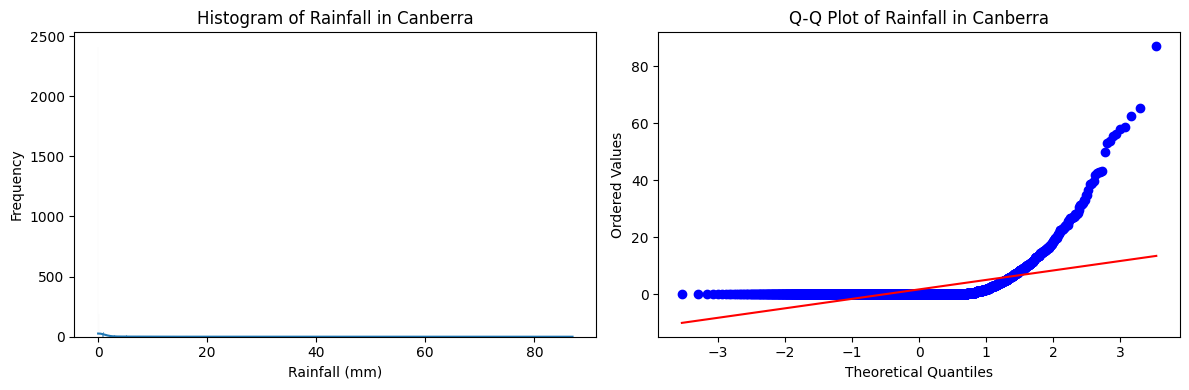

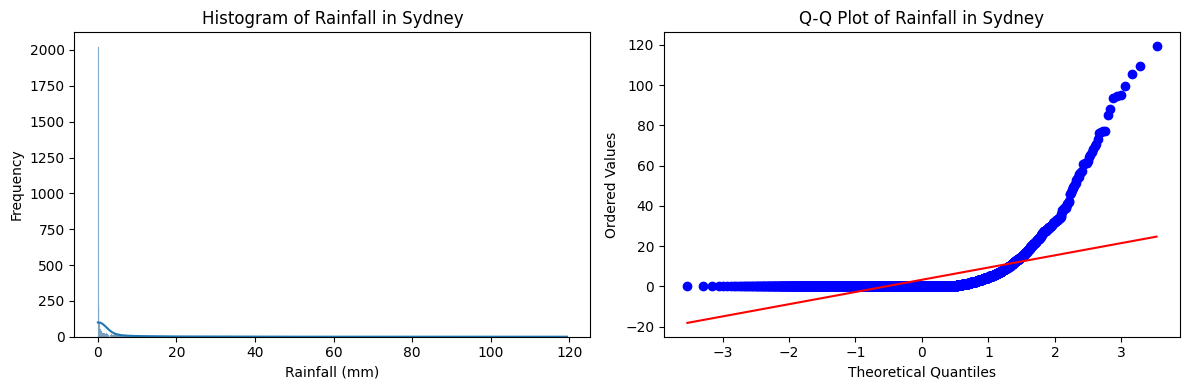

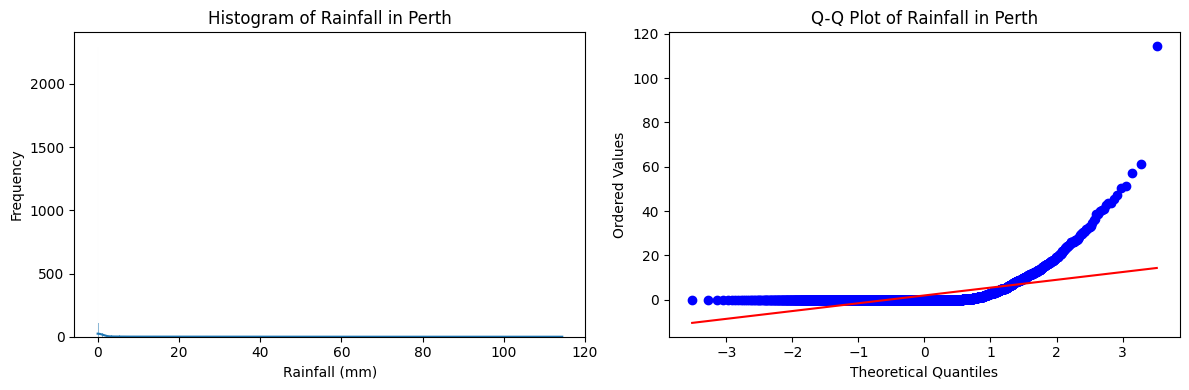

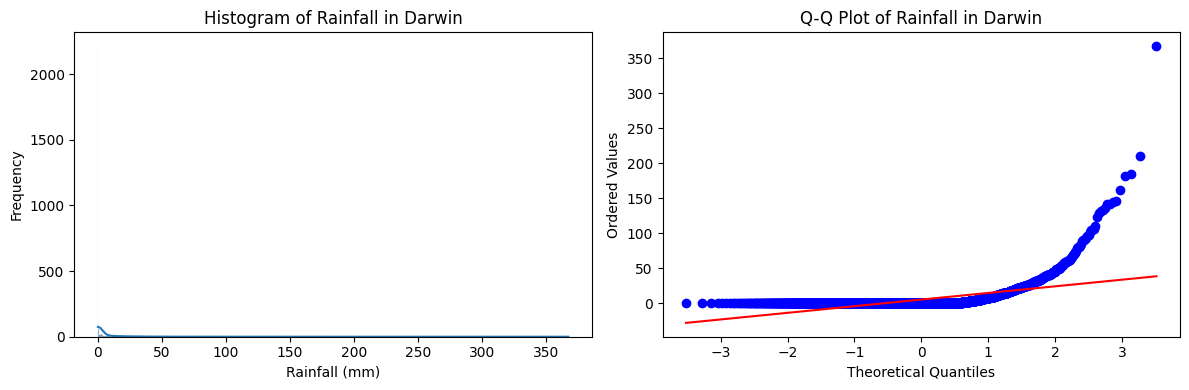

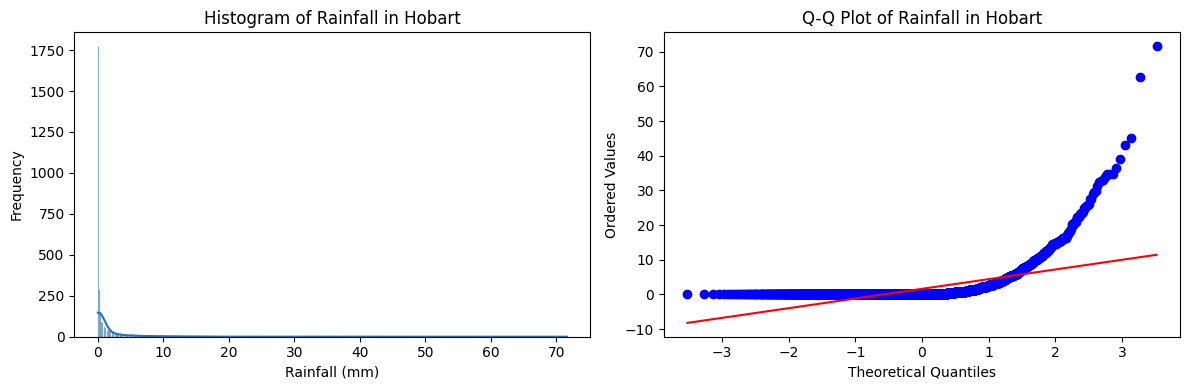

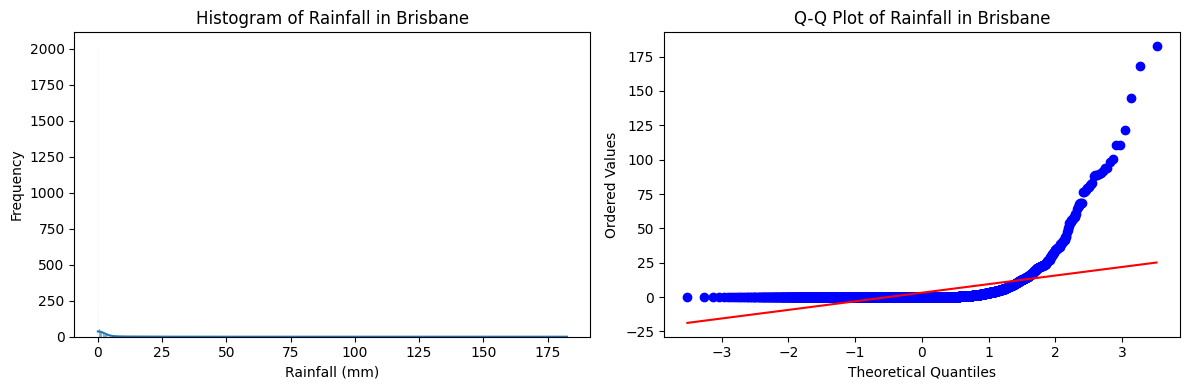

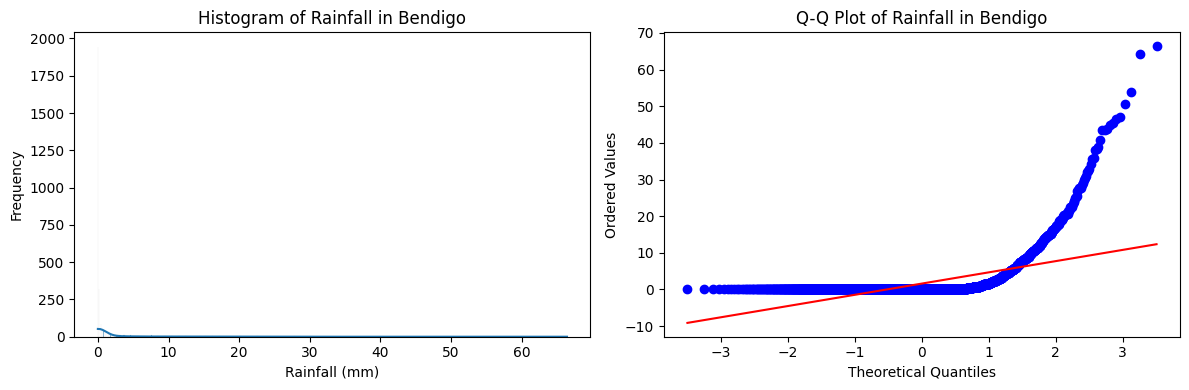

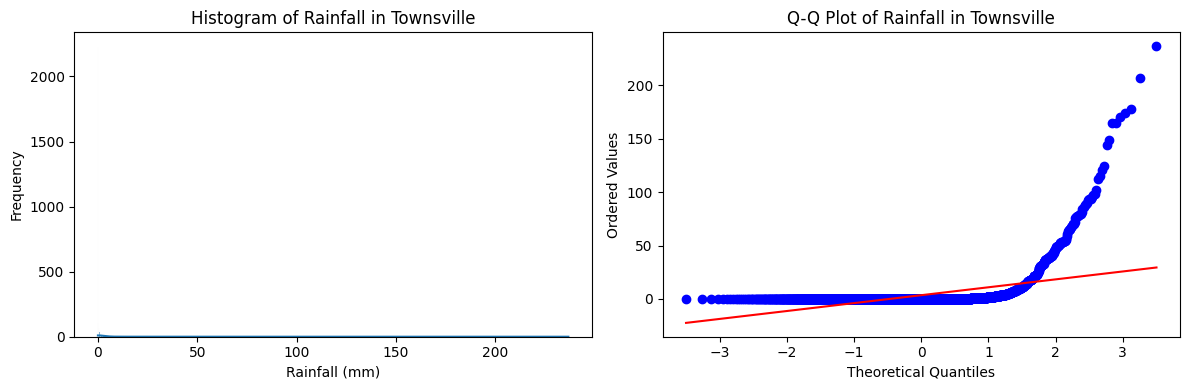

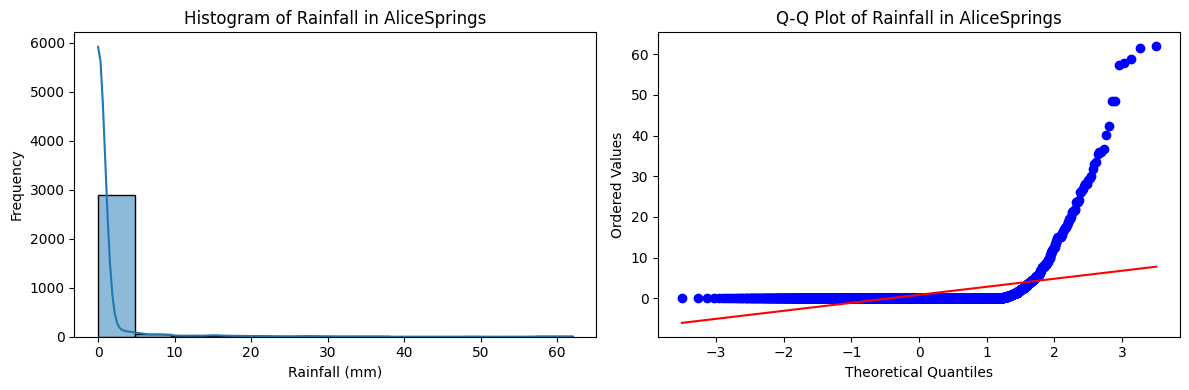

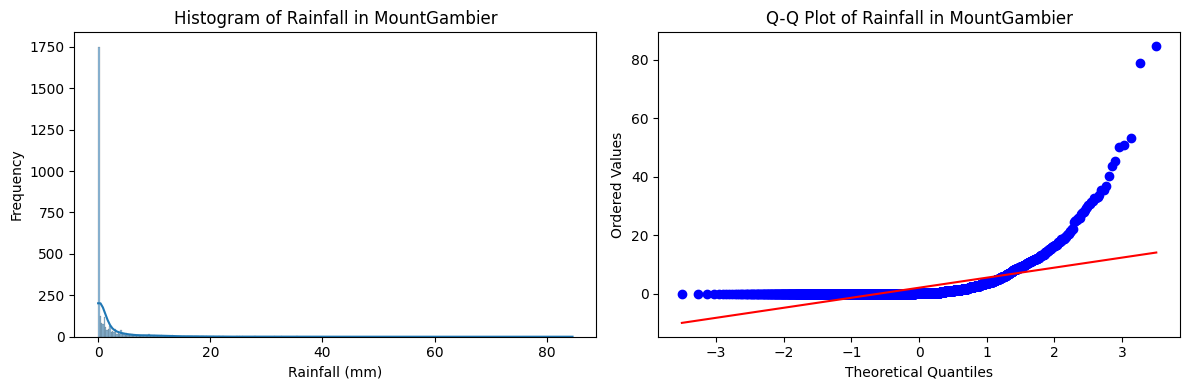

In [96]:
for city in top_cities:
    rainfall_data = subset[subset["Location"] == city]["Rainfall"].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(rainfall_data, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of Rainfall in {city}')
    axes[0].set_xlabel('Rainfall (mm)')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    stats.probplot(rainfall_data, dist='norm', plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of Rainfall in {city}')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Ordered Values')

    plt.tight_layout()
    plt.show()

Although the dataset is large the variables taken into consideration shows an extemely positive skewed behaviour the normality assumption violates. Therefor the Kruskal-Wallis is chosen over the ANOVA test
<br><br>

**Hypothesis Definition for Kruskal-Wallis test**

*   H0 (Null hypothesis) = There is no significant difference in rainfall distribution across the selected cities.
*   H1 (Alternative hypothesis) = There is a significant difference in rainfall distribution across the selected cities."

In [97]:
# Perform Kruskal-Wallis Test
h_stat, p_val_kruskal = kruskal(*groups)

print("Rainfall differences across cities (Kruskal-Wallis Test)")
print(f"H-statistic = {h_stat:.4f}")
print(f"p-value = {p_val_kruskal:.4f}\n")

alpha = 0.05
if p_val_kruskal < alpha:
  print("Reject the null hypothesis: There is a significant difference in rainfall distribution across the selected cities.")
else:
  print("Fail to reject the null hypothesis: There is no significant difference in rainfall distribution across the selected cities.")

Rainfall differences across cities (Kruskal-Wallis Test)
H-statistic = 1232.9982
p-value = 0.0000

Reject the null hypothesis: There is a significant difference in rainfall distribution across the selected cities.
